# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [1]:
# ============================================================
# 1.1 Conditional Logic
# ============================================================

def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif 0 < n <= 10:
        return "small positive"
    else:
        return "large positive"

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0) == "zero"
assert classify_number(7) == "small positive"
assert classify_number(42) == "large positive"

print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

word_count = {}

for word in words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

unique_words = set(words)

long_words = [word for word in words if len(word) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}

print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
def safe_divide(a, b):

    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")

    try:
        return a / b
    except ZeroDivisionError:
        return None

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None

try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"

print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)

assert result == 36

print("1.4 passed ✓")

1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [6]:
import numpy as np

arr1d = np.arange(12)

arr2d = arr1d.reshape(3, 4)

arr3d = arr1d.reshape(2, 2, 3)

print(arr1d)
print(arr2d)
print(arr3d)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)

print("2.1 passed ✓")

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
2.1 passed ✓


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:


row2 = arr2d[1]

col3 = arr2d[:, 2]

sub = arr2d[1:, 2:]

gt7 = arr2d[arr2d > 7]

print(row2)
print(col3)
print(sub)
print(gt7)

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]

print("2.2 passed ✓")

[4 5 6 7]
[ 2  6 10]
[[ 6  7]
 [10 11]]
[ 8  9 10 11]
2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [8]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C = A * B

D = A @ B

dp = np.dot([1, 2, 3], [4, 5, 6])

E = A * 3

print(C)
print(D)
print(dp)
print(E)

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])

print("2.3 passed ✓")

[[ 5 12]
 [21 32]]
[[19 22]
 [43 50]]
32
[[ 3  6]
 [ 9 12]]
2.3 passed ✓


---
## Part 3 — Pandas

In [10]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

      name  age  salary   department
0    Alice   25   50000           HR
1      Bob   30   60000    Marketing
2  Charlie   35   90000  Engineering
3    David   40  120000  Engineering
4      Eva   28   75000      Finance
3.1 passed ✓


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [11]:
import pandas as pd

data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'age': [25, 30, 35, 40, 28],
    'salary': [50000, 60000, 90000, 120000, 75000],
    'department': ['HR', 'Marketing', 'Engineering', 'Engineering', 'Finance']
}

df = pd.DataFrame(data)

salary_series = df['salary']

name_dept_df = df[['name', 'department']]

print(df)

# Tests
assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)

print("3.1 passed ✓")

      name  age  salary   department
0    Alice   25   50000           HR
1      Bob   30   60000    Marketing
2  Charlie   35   90000  Engineering
3    David   40  120000  Engineering
4      Eva   28   75000      Finance
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [12]:
iloc_result = df.iloc[1:4, 0:3]

loc_result = df.loc[0:2, ['name', 'salary']]

print(iloc_result)
print(loc_result)

# Tests
assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']

print("3.2 passed ✓")

      name  age  salary
1      Bob   30   60000
2  Charlie   35   90000
3    David   40  120000
      name  salary
0    Alice   50000
1      Bob   60000
2  Charlie   90000
3.2 passed ✓


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [13]:
senior_eng = df[
    (df['department'] == 'Engineering') &
    (df['salary'] > 80000)
]

dept_stats = (
    df.groupby('department')
      .agg({
          'salary': ['mean', 'max'],
          'age': 'mean'
      })
)

print(senior_eng)
print(dept_stats)

# Tests
assert len(senior_eng) == 2

print("3.3 passed ✓")

      name  age  salary   department
2  Charlie   35   90000  Engineering
3    David   40  120000  Engineering
               salary           age
                 mean     max  mean
department                         
Engineering  105000.0  120000  37.5
Finance       75000.0   75000  28.0
HR            50000.0   50000  25.0
Marketing     60000.0   60000  30.0
3.3 passed ✓


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [14]:
df_missing = df.copy()

df_missing.loc[1, 'salary'] = np.nan
df_missing.loc[3, 'department'] = np.nan

df_filled = df_missing.copy()

df_filled['salary'] = df_filled['salary'].fillna(
    df_filled['salary'].mean()
)

for col in df_filled.select_dtypes(include='object').columns:
    df_filled[col] = df_filled[col].fillna(
        df_filled[col].mode()[0]
    )

print(df_filled)

# Tests
assert df_filled.isnull().sum().sum() == 0

print("3.4 passed ✓")

      name  age    salary   department
0    Alice   25   50000.0           HR
1      Bob   30   83750.0    Marketing
2  Charlie   35   90000.0  Engineering
3    David   40  120000.0  Engineering
4      Eva   28   75000.0      Finance
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

In [15]:
# ============================================================
# 4.1 Vector and Matrix Basics
# ============================================================

v = np.array([3, 4])

norm_v = np.linalg.norm(v)

M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(norm_v)
print(M)

# Tests
assert norm_v == 5

print("4.1 passed ✓")

5.0
[[1 2 3]
 [4 5 6]
 [7 8 9]]
4.1 passed ✓


### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [16]:
P = np.array([[1, 2], [3, 4]])
Q = np.array([[5, 6], [7, 8]])

PplusQ = P + Q

scalar3P = 3 * P

PQ = P @ Q

QTP = Q.T @ P

print(PplusQ)
print(scalar3P)
print(PQ)
print(QTP)

# Tests
assert PplusQ.shape == (2, 2)

print("4.2 passed ✓")

[[ 6  8]
 [10 12]]
[[ 3  6]
 [ 9 12]]
[[19 22]
 [43 50]]
[[26 38]
 [30 44]]
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

Eigenvectors represent special directions that remain unchanged after a matrix transformation, while eigenvalues represent how much the vector is stretched or compressed along those directions. A matrix transformation can rotate, stretch, or squish vectors, but eigenvectors preserve their direction after transformation.

In [17]:
A = np.array([
    [2, 1],
    [1, 2]
])

eigenvalues, eigenvectors = np.linalg.eig(A)

print(eigenvalues)
print(eigenvectors)

# Tests
assert len(eigenvalues) == 2

print("4.3 passed ✓")

[3. 1.]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
4.3 passed ✓


**Your Geometric Explanation (4.3):**

> *Replace this text with your explanation of what eigenvalues/eigenvectors mean geometrically — what does it mean for a matrix to "stretch" or "squish" a vector?*

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In Singular Value Decomposition (SVD), U contains the left singular vectors, S contains the singular values, and Vt contains the right singular vectors. The singular values represent the importance or variance captured by each component. In PCA, the principal components are obtained from the right singular vectors in Vt, which represent the directions of maximum variance in the data.

In [18]:
X = np.array([
    [1, 2],
    [3, 4]
])

U, S, Vt = np.linalg.svd(X)

X_reconstructed = U @ np.diag(S) @ Vt

print(U)
print(S)
print(Vt)

# Tests
assert np.allclose(X, X_reconstructed)

print("4.4 passed ✓")

[[-0.40455358 -0.9145143 ]
 [-0.9145143   0.40455358]]
[5.4649857  0.36596619]
[[-0.57604844 -0.81741556]
 [ 0.81741556 -0.57604844]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

> *Explain: what are U, S, Vt in SVD, and how do they relate to principal components? Which matrix contains the directions of maximum variance?*

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Population: The complete set of all observations or individuals being studied.

Sample: A subset selected from the population for analysis.

Descriptive statistic: A measure used to summarize or describe data, such as mean or standard deviation.

Inferential statistic: A method used to draw conclusions or make predictions about a population using sample data.

In [19]:
salary = df['salary']

mean_s = salary.mean()

median_s = salary.median()

std_s = salary.std()

var_s = salary.var()

print(mean_s)
print(median_s)
print(std_s)
print(var_s)

print("5.1 passed ✓")

79000.0
75000.0
27477.263328068173
755000000.0
5.1 passed ✓


**Definitions (5.1):**

- **Population:** ...
- **Sample:** ...
- **Descriptive statistic:** ...
- **Inferential statistic:** ...

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

H₀: Engineering salaries are equal to the overall company average salary.

H₁: Engineering salaries are significantly higher than the overall company average salary.

Conclusion: Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is not enough statistical evidence to conclude that Engineering salaries are significantly higher than the company average.

In [20]:
from scipy import stats

eng_salaries = df[df['department'] == 'Engineering']['salary']

overall_mean = df['salary'].mean()

t_stat, p_value = stats.ttest_1samp(
    eng_salaries,
    overall_mean
)

print(t_stat)
print(p_value)

print("5.2 passed ✓")

1.7333333333333334
0.33312932632054804
5.2 passed ✓


**H₀ / H₁ and Interpretation (5.2):**

- H₀: ...
- H₁: ...
- Conclusion: ...

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [21]:
# ============================================================
# 5.3 Regression Metrics
# ============================================================

y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

mae_val = mae(y_true, y_pred)
mse_val = mse(y_true, y_pred)
rmse_val = rmse(y_true, y_pred)
mape_val = mape(y_true, y_pred)

print(mae_val)
print(mse_val)
print(rmse_val)
print(mape_val)

print("5.3 passed ✓")

0.5
0.375
0.6123724356957945
32.73809523809524
5.3 passed ✓


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [23]:
from statsmodels.tsa.stattools import adfuller

s1 = np.random.normal(0, 1, 1000)
s2 = np.random.normal(0.5, 1, 1000)

ks_stat, ks_p = stats.ks_2samp(s1, s2)

random_walk = np.cumsum(np.random.randn(300))

adf_result = adfuller(random_walk)

print("KS Statistic:", ks_stat)
print("KS p-value:", ks_p)

print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

print("5.4 passed ✓")

KS Statistic: 0.222
KS p-value: 5.356249099254043e-22
ADF Statistic: 0.014297832227501042
ADF p-value: 0.9596986551372158
5.4 passed ✓


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

Concept drift: The relationship between input features and the target variable changes over time.

Covariate drift: The distribution of input features changes over time while the relationship with the target remains similar.

PSI < 0.1: No significant distribution shift.

PSI 0.1–0.2: Moderate shift; monitoring is recommended.

PSI > 0.2: Major shift; retraining may be required.

Retraining trigger example: A significant drop in model accuracy or PSI consistently above 0.2.

In [24]:
def compute_psi(expected, actual, bins=10):

    expected_percents, bin_edges = np.histogram(
        expected,
        bins=bins
    )

    actual_percents, _ = np.histogram(
        actual,
        bins=bin_edges
    )

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    expected_percents = np.where(
        expected_percents == 0,
        0.0001,
        expected_percents
    )

    actual_percents = np.where(
        actual_percents == 0,
        0.0001,
        actual_percents
    )

    psi = np.sum(
        (actual_percents - expected_percents) *
        np.log(actual_percents / expected_percents)
    )

    return psi

expected = np.random.normal(0, 1, 1000)
actual = np.random.normal(0.2, 1.2, 1000)

psi_value = compute_psi(expected, actual)

print("PSI:", psi_value)

print("5.5 passed ✓")

PSI: 0.12481051150426944
5.5 passed ✓


**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** ...
- **Covariate drift:** ...
- **PSI < 0.1:** ...
- **PSI 0.1–0.2:** ...
- **PSI > 0.2:** ...
- **Retraining trigger example:** ...

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [25]:
red = 4
blue = 3
green = 3

total = red + blue + green

p_red = red / total

p_blue = blue / total

p_green = green / total

p_not_red = 1 - p_red

p_red_or_blue = p_red + p_blue

print(p_red)
print(p_not_red)
print(p_red_or_blue)

print("6.1 passed ✓")

0.4
0.6
0.7
6.1 passed ✓


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

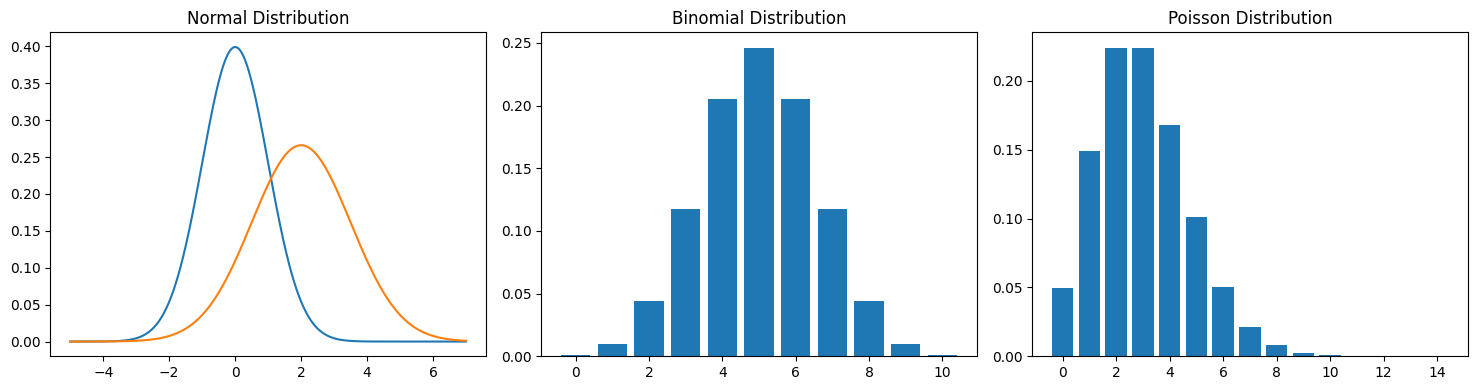

6.2 passed ✓


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Normal Distribution
x = np.linspace(-5, 7, 500)

y1 = stats.norm.pdf(x, 0, 1)
y2 = stats.norm.pdf(x, 2, 1.5)

axes[0].plot(x, y1)
axes[0].plot(x, y2)
axes[0].set_title("Normal Distribution")

# Binomial Distribution
x_bin = np.arange(0, 11)
y_bin = stats.binom.pmf(x_bin, 10, 0.5)

axes[1].bar(x_bin, y_bin)
axes[1].set_title("Binomial Distribution")

# Poisson Distribution
x_pois = np.arange(0, 15)
y_pois = stats.poisson.pmf(x_pois, 3)

axes[2].bar(x_pois, y_pois)
axes[2].set_title("Poisson Distribution")

plt.tight_layout()
plt.show()

print("6.2 passed ✓")

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

| Term | Formula | In this example |
|------|----------|----------------|
| Prior | P(Spam) | Probability that an email is spam before seeing the word |
| Likelihood | P(word \| Spam) | Probability of the word "free" appearing in spam emails |
| Evidence | P(word) | Overall probability of seeing the word "free" |
| Posterior | P(Spam \| word) | Probability that the email is spam given the word "free" |

In [27]:
p_spam = 0.3
p_ham = 0.7

p_free_given_spam = 0.8
p_free_given_ham = 0.1

p_free = (
    p_free_given_spam * p_spam +
    p_free_given_ham * p_ham
)

p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print(p_spam_given_free)

print("6.3 passed ✓")

0.7741935483870968
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | ... |
| Likelihood | P(word \| Spam) | ... |
| Evidence | P(word) | ... |
| Posterior | P(Spam \| word) | ... |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

The Central Limit Theorem is important because it explains why sample means tend to follow a normal distribution even when the original population is not normally distributed. This property allows many statistical methods and machine learning algorithms to rely on normality assumptions. The CLT justifies the use of hypothesis testing, confidence intervals, and regression analysis in practical applications.

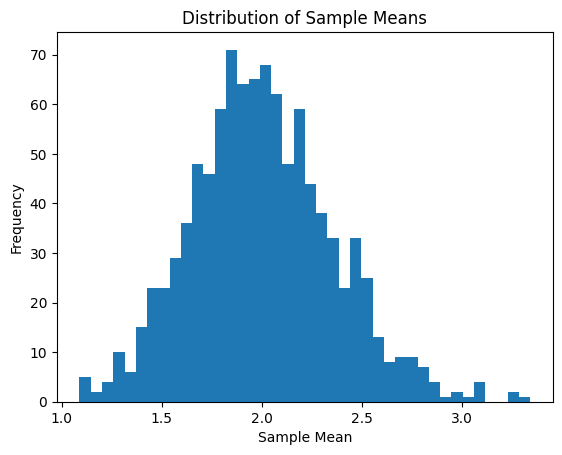

6.4 passed ✓


In [28]:
population = np.random.exponential(scale=2, size=10000)

sample_means = []

sample_size = 30
n_samples = 1000

for _ in range(n_samples):

    sample = np.random.choice(
        population,
        size=sample_size
    )

    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

plt.hist(sample_means, bins=40)

plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

print("6.4 passed ✓")

**CLT Reflection (6.4):**

> *In 2–3 sentences: Why does this result matter for statistics and machine learning? What assumption does the CLT justify in many classical statistical tests?*

---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`